In [ ]:
# Datasets standard (tous inclus dans scikit-learn)
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

iris       = datasets.load_iris()           # 150 x 4, 3 classes
breast     = datasets.load_breast_cancer()  # 569 x 30, binaire
wine       = datasets.load_wine()           # 178 x 13, 3 classes
digits     = datasets.load_digits()         # 1797 x 64, 10 classes
diabetes   = datasets.load_diabetes()       # 442 x 10, regression
california = datasets.fetch_california_housing()  # 20640 x 8, prix

data = datasets.load_iris()
X = data.data
y = data.target

# Split stratifié 80/20
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify pour classification
)

# Pipeline : evite le data leakage (scaler ajuste uniquement sur train)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
model = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(random_state=42))])


In [ ]:
# Datasets standard (tous inclus dans scikit-learn)
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

iris       = datasets.load_iris()           # 150 x 4, 3 classes
breast     = datasets.load_breast_cancer()  # 569 x 30, binaire
wine       = datasets.load_wine()           # 178 x 13, 3 classes
digits     = datasets.load_digits()         # 1797 x 64, 10 classes
diabetes   = datasets.load_diabetes()       # 442 x 10, regression
california = datasets.fetch_california_housing()  # 20640 x 8, prix

data = datasets.load_iris()
X = data.data
y = data.target

# Split stratifié 80/20
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify pour classification
)

# Pipeline : evite le data leakage (scaler ajuste uniquement sur train)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
model = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(random_state=42))])


In [ ]:
# Datasets standard (tous inclus dans scikit-learn)
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

iris       = datasets.load_iris()           # 150 x 4, 3 classes
breast     = datasets.load_breast_cancer()  # 569 x 30, binaire
wine       = datasets.load_wine()           # 178 x 13, 3 classes
digits     = datasets.load_digits()         # 1797 x 64, 10 classes
diabetes   = datasets.load_diabetes()       # 442 x 10, regression
california = datasets.fetch_california_housing()  # 20640 x 8, prix

data = datasets.load_iris()
X = data.data
y = data.target

# Split stratifié 80/20
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify pour classification
)

# Pipeline : evite le data leakage (scaler ajuste uniquement sur train)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
model = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(random_state=42))])


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

# Load and split the iris dataset for this cell
iris_data = datasets.load_iris()
X_iris = iris_data.data
y_iris = iris_data.target
X_iris_tr, X_iris_te, y_iris_tr, y_iris_te = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

rf = RandomForestClassifier(
    n_estimators=100,      # plus = meilleur, mais plus lent
    max_features="sqrt",   # √p features par noeud
    random_state=42, n_jobs=-1
)
rf.fit(X_iris_tr, y_iris_tr)

# Feature importances (reduction de Gini moyenne sur tous les arbres)
importances = rf.feature_importances_

# Diagnostiquer l'overfitting
# Use the iris dataset for learning_curve as X and y are not defined globally for this specific context
train_sz, train_sc, test_sc = learning_curve(rf, X_iris, y_iris, cv=5)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Load and split the breast cancer dataset for this cell
bc_data = datasets.load_breast_cancer()
X_bc = bc_data.data
y_bc = bc_data.target
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

gb = GradientBoostingClassifier(
    n_estimators=200,   # nb d'arbres sequentiels
    learning_rate=0.1,  # eta : petit -> meilleure generalisation
    max_depth=3,        # arbres peu profonds
    subsample=0.8,      # stochastic GBM
    random_state=42
)
gb.fit(X_bc_tr, y_bc_tr)
proba = gb.predict_proba(X_bc_te)[:, 1]  # probabilite classe positive

# Convergence : accuracy par iteration
staged = [accuracy_score(y_bc_te, p) for p in gb.staged_predict(X_bc_te)]

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score # Import accuracy_score

# Load and split the breast cancer dataset for this cell
bc_data = datasets.load_breast_cancer()
X_bc = bc_data.data
y_bc = bc_data.target
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

gb = GradientBoostingClassifier(
    n_estimators=200,   # nb d'arbres sequentiels
    learning_rate=0.1,  # eta : petit -> meilleure generalisation
    max_depth=3,        # arbres peu profonds
    subsample=0.8,      # stochastic GBM
    random_state=42
)
gb.fit(X_bc_tr, y_bc_tr)
proba = gb.predict_proba(X_bc_te)[:, 1]  # probabilite classe positive

# Convergence : accuracy par iteration
staged = [accuracy_score(y_bc_te, p) for p in gb.staged_predict(X_bc_te)]

In [ ]:
from sklearn.svm import SVC

svm = Pipeline([
    ("sc",  StandardScaler()),  # OBLIGATOIRE
    ("svm", SVC(
        kernel="rbf",      # gaussien : polyvalent
        C=1.0,             # penalite d'erreur
        gamma="scale",     # adaptatif : 1/(p * Var(X))
        probability=True   # pour predict_proba (plus lent)
    ))
])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Trouver le k optimal
for k in range(1, 21):
    knn = Pipeline([("sc", StandardScaler()),
                    ("knn", KNeighborsClassifier(n_neighbors=k))])
    knn.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, knn.predict(X_te))

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()    # pas de normalisation necessaire
gnb.fit(X_tr, y_tr)
proba = gnb.predict_proba(X_te)   # probabilites posterieures calibrees

print(gnb.theta_)  # (n_classes, n_features) : moyennes par classe
print(gnb.var_)    # (n_classes, n_features) : variances par classe

[[4.985  3.415  1.4775 0.255 ]
 [5.93   2.75   4.2525 1.32  ]
 [6.61   2.98   5.58   2.04  ]]
[[0.092775   0.155275   0.02524375 0.012975  ]
 [0.2216     0.093      0.19149375 0.0341    ]
 [0.4574     0.1221     0.3236     0.0704    ]]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.9 MB/s eta 0:00:00


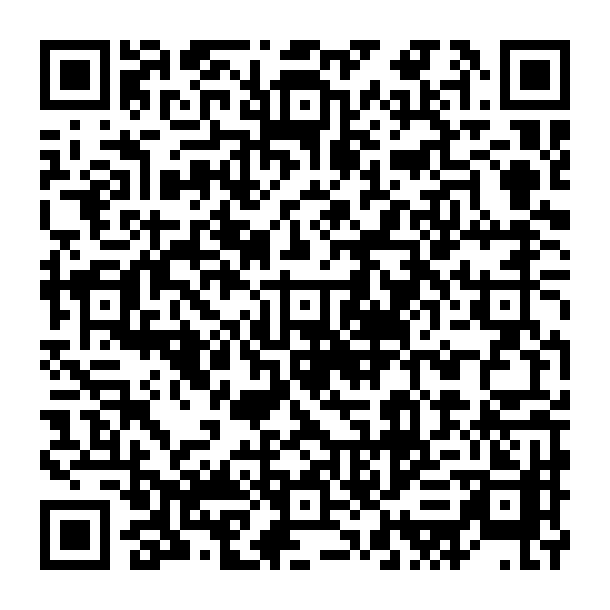

In [12]:
!pip install qrcode[pil]

import qrcode

url = "https://colab.research.google.com/drive/1IALWXw5R4bwWy-LPYMQBfbFwnKrQFSIs#scrollTo=rHj8o7Mae-r9"

qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=10,
    border=4,
)
qr.add_data(url)
qr.make(fit=True)

img = qr.make_image(fill_color="black", back_color="white")
img.save("qrcode_colab.png")

from IPython.display import Image
Image("qrcode_colab.png")